In [1]:
import os 

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = 'cifar10/cifar10/cifar10/train/'
test_path = 'cifar10/cifar10/cifar10/test/'

gen_train_data = ImageDataGenerator(rescale=1./255)
gen_test_data = ImageDataGenerator(rescale=1./255)

train_generator = gen_train_data.flow_from_directory(train_path,target_size=(32,32),batch_size=32,class_mode='categorical')
test_generator = gen_test_data.flow_from_directory(test_path,target_size=(32,32),batch_size=32,class_mode='categorical')

Found 50000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
model=Sequential()



In [12]:
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D(2,2))


In [13]:

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [14]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


In [15]:
model.fit(train_generator,epochs=10,verbose=1)

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 507s 322ms/step - accuracy: 0.3342 - loss: 1.7779
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 259s 166ms/step - accuracy: 0.5668 - loss: 1.2138
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 325s 208ms/step - accuracy: 0.6426 - loss: 1.0170
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.6871 - loss: 0.8929
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7188 - loss: 0.7876
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.7410 - loss: 0.7296
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7660 - loss: 0.6641
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.7857 - loss: 0.6104
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.8010 - loss: 0.5645
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.8158 - loss: 0.5219


In [16]:
loss,accuracy=model.evaluate(test_generator)
print(accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 307ms/step - accuracy: 0.7258 - loss: 0.8531
0.7260000109672546


In [17]:
model.save('CIFAR 10 model.keras')


In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


In [27]:
img_path='cifar10/cifar10/cifar10/test/dog/0004.png'

In [28]:
img=image.load_img(img_path,target_size=(32,32))
img_array=image.img_to_array(img)
img_array=img_array/255.0
img_array=np.expand_dims(img_array,axis=0)



In [29]:
pred = model.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [30]:
pred_index=np.argmax(pred)
confidence=np.max(pred)


In [31]:
pred_label=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck',]
predicted_label=pred_label[pred_index]

In [32]:
print (f"predicated class: {predicted_label} (confidence: {confidence:.2f})")

predicated class: dog (confidence: 0.86)


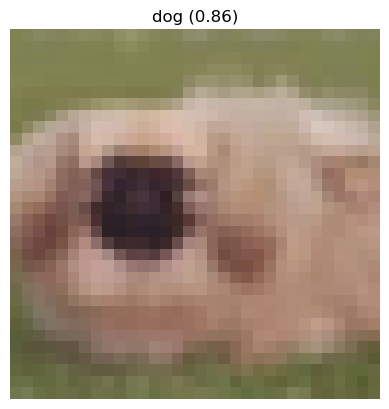

In [33]:
plt.imshow(img)
plt.title(f"{predicted_label} ({confidence:.2f})")
plt.axis('off')
plt.show()